<a href="https://colab.research.google.com/github/kswkm/ml-models-practice/blob/main/notebooks/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 데이터 경로 설정
# 로컬(Jupyter): 저장소의 data/ 폴더를 그대로 사용
# Colab: 저장소를 복제한 뒤 같은 data/ 폴더를 사용
import sys
import subprocess
from pathlib import Path

if 'google.colab' in sys.modules and not Path('ml-models-practice').exists():
    subprocess.run(['git', 'clone', '-q', 'https://github.com/kswkm/ml-models-practice.git'], check=True)

DATA_DIR = next(p for p in [Path('data'), Path('../data'), Path('ml-models-practice/data')] if p.exists())
DATA_DIR

In [4]:
import pandas as pd
df = pd.read_csv(DATA_DIR / 'raw' / 'penguins_size.csv')
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [7]:
df.dropna(inplace=True)
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [8]:
df['sex'].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [9]:
df[df['sex']=='.']

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


In [10]:
df.drop(axis=0, inplace=True, index=336)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   culmen_length_mm   333 non-null    float64
 3   culmen_depth_mm    333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [11]:
df['species'].value_counts()

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


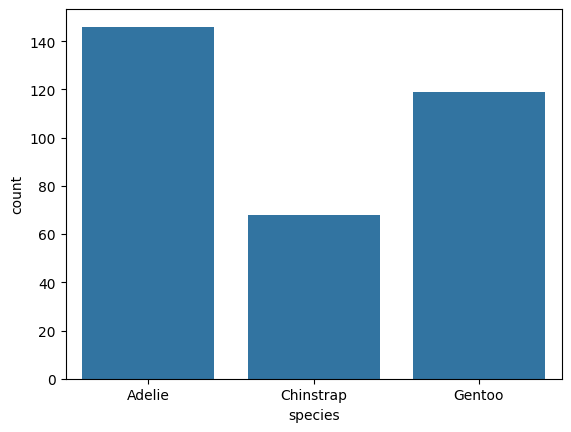

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='species', data=df)
plt.show()

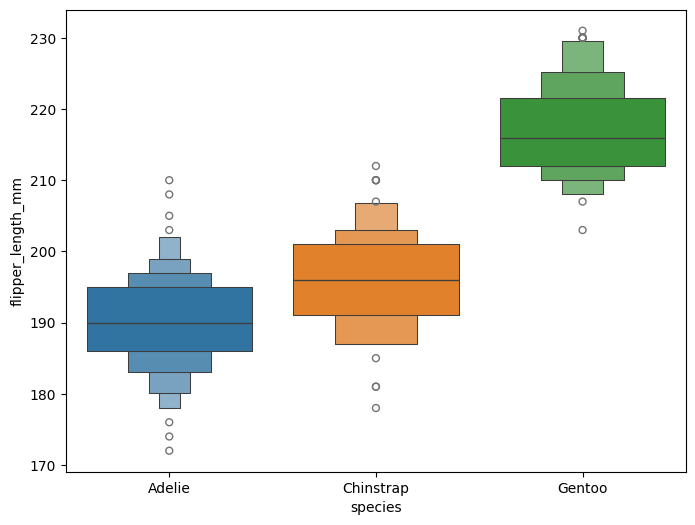

In [13]:
plt.figure(figsize=(8, 6))
sns.boxenplot(x='species', y='flipper_length_mm', hue='species', data=df)
plt.show()

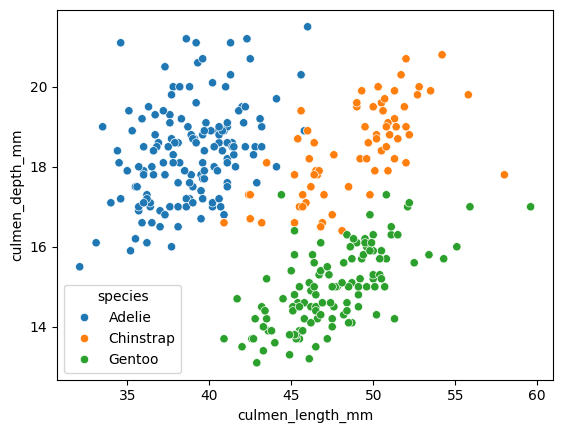

In [14]:
sns.scatterplot(x='culmen_length_mm', y='culmen_depth_mm', hue='species', data=df)
plt.show()

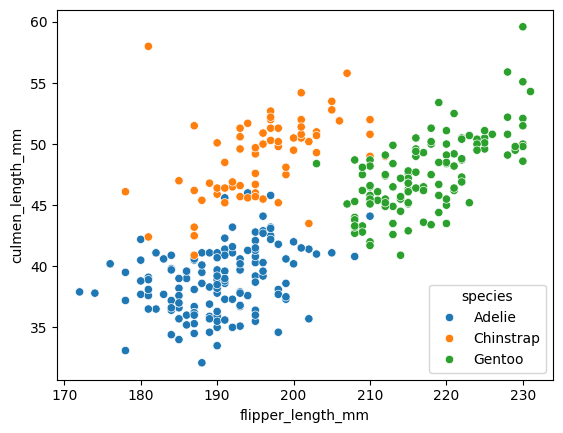

In [15]:
sns.scatterplot(x='flipper_length_mm', y='culmen_length_mm', hue='species', data=df)
plt.show()

In [ ]:
X = df.drop('sex', axis=1)
y = df['sex']

In [ ]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_features = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['species', 'island']

#범주형 특징은 원-핫 인코딩, 수치형 특징은 min-max 정규화
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', MinMaxScaler(), numerical_features)
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

#전처리 기준(최솟값·최댓값, 범주 목록)은 훈련 데이터에서만 학습 (데이터 누수 방지)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
X_train[0]

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

In [ ]:
print("훈련 데이터를 이용한 모델 분류 정확도: ", knn.score(X_train, y_train))
print("테스트 데이터를 이용한 모델 성능 평가: ", knn.score(X_test, y_test))

In [ ]:
#k 값에 따른 정확도 비교
#최종 모델(knn, k=7)을 덮어쓰지 않도록 별도 변수(knn_k)를 사용
for k in range(2, 21):
  knn_k = KNeighborsClassifier(n_neighbors=k)
  knn_k.fit(X_train, y_train)
  score = knn_k.score(X_test, y_test)
  print('k: %d, accuracy: %.2f' % (k, score*100))

In [ ]:
predictions = knn.predict(X_test)

In [ ]:
print(predictions[:5])
print(y_test[:5])

In [ ]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8, 6))

conf = confusion_matrix(y_test, predictions)
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', xticklabels=knn.classes_, yticklabels=knn.classes_)

plt.title("Penguins Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
df_new = pd.read_csv(DATA_DIR / 'new' / 'penguin_new.csv')
df_new.head()

,culmen_depth_mm,culmen_length_mm,flipper_length_mm
0,18.7,39.1,181
1,18.5,46.9,200
2,14.5,50.0,250


In [ ]:
#새 데이터에는 부리 길이·부리 깊이·날개 길이 3개 특징만 있음
#없는 특징(종, 섬, 체중)을 임의 값으로 채우면 예측이 그 임의 값에 좌우되므로,
#새 데이터에 있는 3개 특징만으로 모델을 따로 학습해 예측
new_features = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm']
X3_train, X3_test, y3_train, y3_test = train_test_split(df[new_features], y, test_size=0.3, stratify=y, random_state=0)

scaler3 = MinMaxScaler()
X3_train = scaler3.fit_transform(X3_train)
X3_test = scaler3.transform(X3_test)

knn3 = KNeighborsClassifier(n_neighbors=7)
knn3.fit(X3_train, y3_train)
print("3개 특징 모델 테스트 정확도: ", knn3.score(X3_test, y3_test))

#새 데이터의 열 순서가 달라도 이름으로 골라 같은 순서로 맞춤
new_scaled = scaler3.transform(df_new[new_features])

In [ ]:
print(knn3.predict(new_scaled))